In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import hdbscan
import optuna
from sklearn.cluster import KMeans, DBSCAN

from Src.data import load_csv_df, save_csv_df
from Src.plotting import set_plotting_style, draw_model_clusters
from Src.model import save_model_result, print_model_result, create_cluster_objective, save_trained_model

C:\Users\User\Desktop\Important\ML\Credit-Card-Clustering\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Already prepared accent palette applying using function from mine Src module (plotting)
set_plotting_style()

In [3]:
DF_PATH = "../Data/Processed/processed-data.csv"

# Safely loading dataframe using function from mine Src module (data)
df = load_csv_df(
    df_path=DF_PATH,
)

df_2d = df[["PCA1", "PCA2"]].copy()

Successfully loaded dataframe: ..\Data\Processed\processed-data.csv
Dataframe has: 8950 rows / 6 columns
Dataframe size: 0.410MB


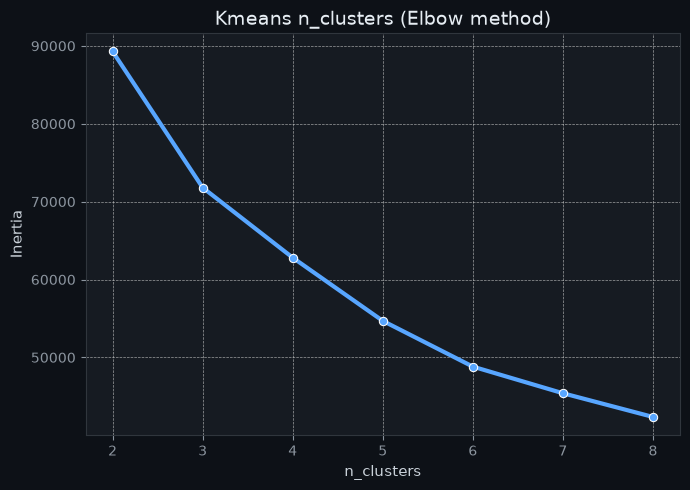

In [4]:
"""I will compare 3 models (KMeans, DBSCAN, HDBSCAN)

First one is KMeans
Second one is DBSCAN
Final is HDBSCAN

All models will be rated by silhouette, davies and calinski metrics
"""
inertia_list = []
n_clusters = range(2, 9)

for n in n_clusters:
    model = KMeans(
        n_clusters=n,
        random_state=42,
        n_init=10
    )
    model.fit(df)
    inertia_list.append(model.inertia_)

plt.figure(figsize=(7, 5))
sns.lineplot(
    x=list(n_clusters),
    y=inertia_list,
    marker="o",
    linewidth=3,
)

plt.title("Kmeans n_clusters (Elbow method)")
plt.xlabel("n_clusters")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

# The best n_clusters is 5
BEST_N_CLUSTERS = 5


                    Clustering Results
model_name  silhouette_score  davies_score  calinski_score
    KMeans             0.271         1.334        3000.519



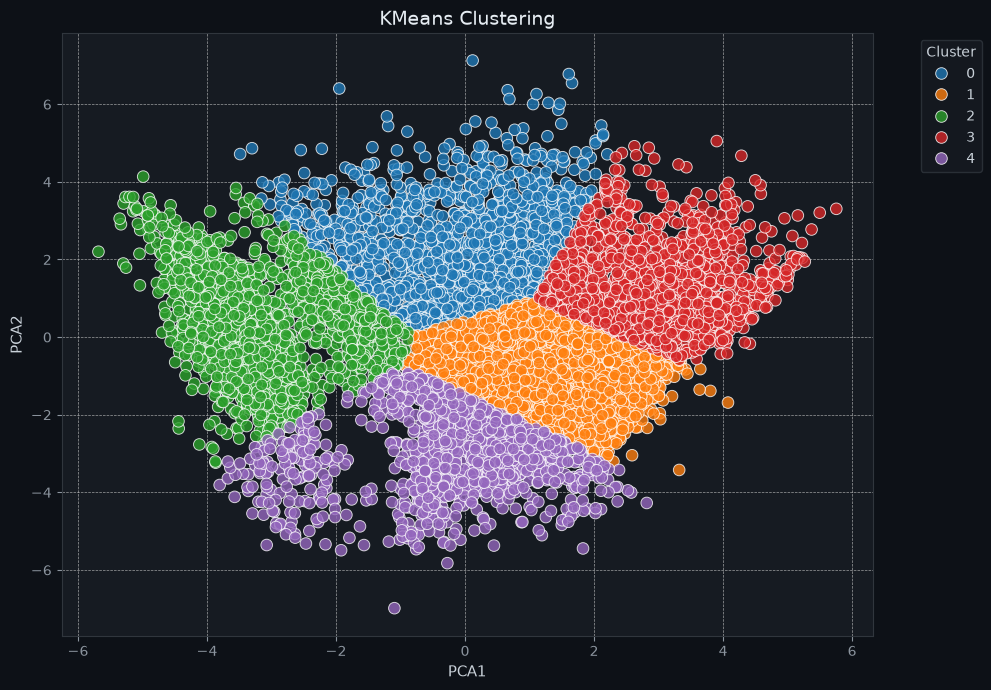

In [5]:
"""
List where will be all 3 model results
There will be model_name, silhouette_score, calinski_harabasz_score, davies_bouldin_score
"""
MODEL_RESULTS = []

kmeans_model = KMeans(
    n_clusters=BEST_N_CLUSTERS,
    random_state=42,
    n_init="auto"
)

# Saving model results using func from mine Src module (model)
MODEL_RESULTS = save_model_result(
    results=MODEL_RESULTS,
    model_name="KMeans",
    x=df,
    model=kmeans_model
)
# Printing all model results using func from mine Src module (model)
print_model_result(MODEL_RESULTS)

# Drawing KMeans clustering using func from mine Src module (plotting)
draw_model_clusters(
    model=kmeans_model,
    title="KMeans Clustering",
    x=df_2d
)

In [6]:
# The next model is DBSCAN
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Creating objective trial for dbscan (optuna) using func from mine Src module (model)
dbscan_objective = create_cluster_objective(
    x=df,
    algorithm="dbscan",
    eps_min=0.3,
    eps_max=0.85,
    min_samples_min=5,
    min_samples_max=20,
    max_noise_ratio=0.7
)

study_dbscan = optuna.create_study(direction="maximize")
study_dbscan.optimize(dbscan_objective, n_trials=50)

print("\n" + "=" * 50)
print(" " * 12 + "DBSCAN Optuna Best Results")
print("=" * 50)
print(f"Best Silhouette Score: {study_dbscan.best_value:.3f}")
print("Best Parameters:")

for param_name, param_value in study_dbscan.best_params.items():
    print(f" - {param_name}: {param_value}")
print("=" * 50 + "\n")

# The best EPS parameter is 0.7 but the best min_samples is 20
BEST_EPS = study_dbscan.best_params["eps"]
BEST_MIN_SAMPLES = int(study_dbscan.best_params["min_samples"])


            DBSCAN Optuna Best Results
Best Silhouette Score: 0.300
Best Parameters:
 - eps: 0.7
 - min_samples: 20



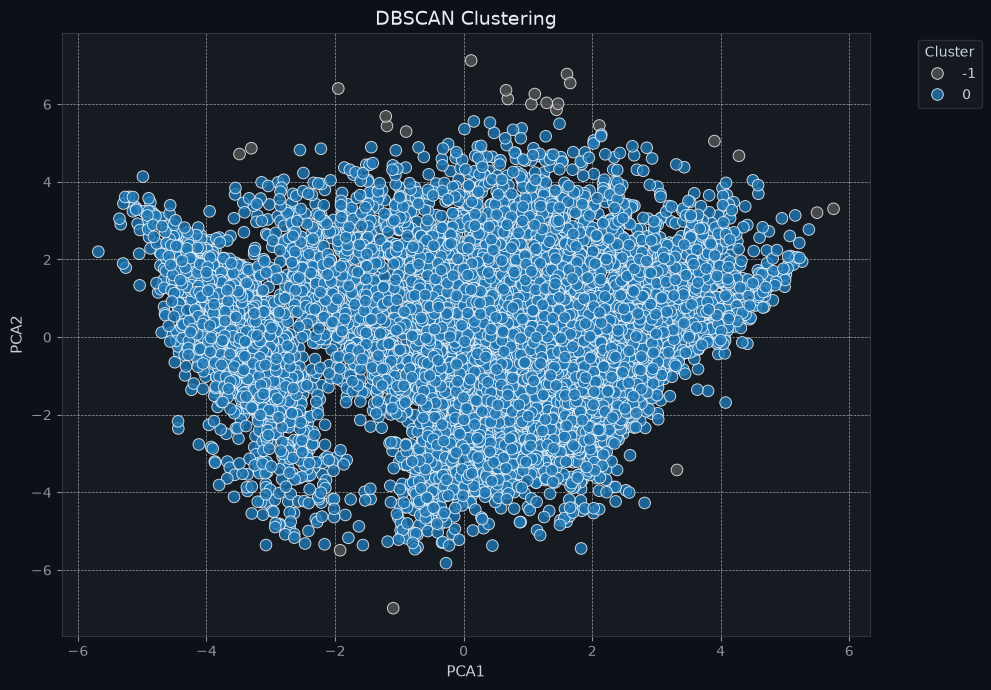

In [7]:
dbscan_model = DBSCAN(
    eps=BEST_EPS,
    min_samples=BEST_MIN_SAMPLES
)

MODEL_RESULTS = save_model_result(
    results=MODEL_RESULTS,
    model_name="DBSCAN",
    x=df,
    model=dbscan_model
)

draw_model_clusters(
    model=dbscan_model,
    title="DBSCAN Clustering",
    x=df_2d
)

In [8]:
# The final model is HDBSCAN
hdbscan_objective = create_cluster_objective(
    x=df,
    algorithm="hdbscan",
    min_cluster_size_min=15,
    min_cluster_size_max=80,
    min_samples_min=5,
    min_samples_max=15,
    max_noise_ratio=0.25
)

study_hdbscan = optuna.create_study(direction="maximize")
study_hdbscan.optimize(hdbscan_objective, n_trials=50)

print("\n" + "=" * 50)
print(" " * 12 + "HDBSCAN Optuna Best Results")
print("=" * 50)
print(f"Best Silhouette Score: {study_hdbscan.best_value:.3f}")
print("Best Parameters:")

for param_name, param_value in study_hdbscan.best_params.items():
    print(f" - {param_name}: {param_value}")
print("=" * 50 + "\n")

# The best MIN_CLUSTER_SIZE parameter is 40 but the best min_samples is 11
BEST_MIN_CLUSTER_SIZE = study_hdbscan.best_params["min_cluster_size"]
BEST_MIN_SAMPLES_HDBSCAN = study_hdbscan.best_params["min_samples"]


            HDBSCAN Optuna Best Results
Best Silhouette Score: 0.240
Best Parameters:
 - min_cluster_size: 16
 - min_samples: 10



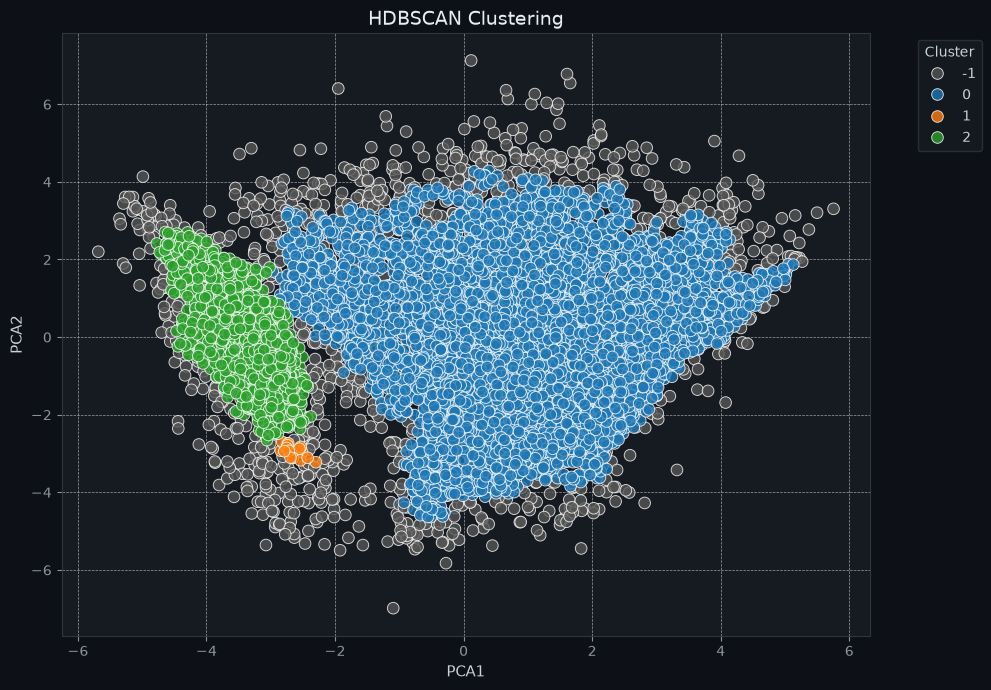

In [9]:
hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=BEST_MIN_CLUSTER_SIZE,
    min_samples=BEST_MIN_SAMPLES_HDBSCAN,
)

MODEL_RESULTS = save_model_result(
    results=MODEL_RESULTS,
    model_name="HDBSCAN",
    x=df,
    model=hdbscan_model
)

draw_model_clusters(
    model=hdbscan_model,
    title="HDBSCAN Clustering",
    x=df_2d
)

In [10]:
# Final results
print_model_result(MODEL_RESULTS)

"""
=================================================================
                    Clustering Results
=================================================================
Dataset: 6 PCA Components
Used models: Kmeans, DBSCAN, HDBSCAN
Hyperparameters optimization: Optuna Framework

1. Results table:
----------------------------------------------------------------
model_name | silhouette_score | davies_score | calinski_score
----------------------------------------------------------------
KMeans     | 0.271            | 1.334        | 3000.519
DBSCAN     | 0.300            | 0.910        | 1968.406
HDBSCAN    | 0.240            | 0.783        | 97.647
----------------------------------------------------------------

2. Key finding and model evaluation:
----------------------------------------------------------------
* HDBSCAN (Best performing model because its show reality separation):
    - Achieved the best silhouette score (0.240) and strong separation quality.
    - Dynamically adapts to variable cluster densities.
    - Utilized 'eom' selection to build robust

* DBSCAN (Density baseline):
    - Reached local performance ceiling (Silhouette = 0.300) due to its global eps
    parameter.
    - Struggle with continuous data distribution where density is stronger.

* KMeans (Non-density baseline):
    - Highest Calinski score (3000.519) because the metric favors spherical
    clusters.
    - Forces 100% of samples into clusters, including sewer outliers (Davies score = 1.334).


Final desition and next steps:
----------------------------------------------------------------
Selected model: HDBSCAN (cluster_selection_method='eom')
Export:
1. Serialized model saved to: "../Models/final-model.pkl"
2. Dataframe with cluster labels exported to: "../Data/Final/final-data.csv"
Proceed to: CP.ipynb (Cluster Profiles) for post-clustering profiling.
"""
FINAL_MODEL = hdbscan.HDBSCAN(
    min_cluster_size=BEST_MIN_CLUSTER_SIZE,
    min_samples=BEST_MIN_SAMPLES_HDBSCAN,
)


                    Clustering Results
model_name  silhouette_score  davies_score  calinski_score
    KMeans             0.271         1.334        3000.519
    DBSCAN             0.300         0.910        1968.406
   HDBSCAN             0.240         0.783          97.647



In [11]:
# Saving model and final dataframe with cluster feature
DF_OUTPUT_PATH = "../Data/Final/final-data.csv"
MODEL_OUTPUT_PATH = "../Models/final-model.pkl"

final_df = df.copy()
final_df["cluster"] = FINAL_MODEL.fit_predict(final_df)

print("\n" + "=" * 65)
save_csv_df(
    df=final_df,
    output_path=DF_OUTPUT_PATH
)

print("\n" + "=" * 65 + "\n")

save_trained_model(
    model=FINAL_MODEL,
    output_path=MODEL_OUTPUT_PATH
)
print("=" * 65)


Successfully saved dataframe: ..\Data\Final\final-data.csv
Dataframe has: 8950 rows / 7 columns
Dataframe memory usage: 0.478MB


Successfully saved model: ..\Models\final-model.pkl
Model algorithm: HDBSCAN
Model file size: 1.096MB
